In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

In [31]:
# Load the cleaned dataset generated from the data cleaning step
df = pd.read_csv("music_cleaned.csv")

# Display basic structure of the dataset
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 18)


,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.002,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [32]:
# Display information about data types and non-null counts
print(df.info())

# Display summary statistics for numerical variables
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       50000 non-null  float64
 1   artist_name       50000 non-null  object 
 2   track_name        50000 non-null  object 
 3   popularity        50000 non-null  float64
 4   acousticness      50000 non-null  float64
 5   danceability      50000 non-null  float64
 6   duration_ms       50000 non-null  float64
 7   energy            50000 non-null  float64
 8   instrumentalness  50000 non-null  float64
 9   key               50000 non-null  object 
 10  liveness          50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  mode              50000 non-null  object 
 13  speechiness       50000 non-null  float64
 14  tempo             50000 non-null  float64
 15  obtained_date     50000 non-null  object 
 16  valence           50000 non-null  float6

In [33]:
unique_keys = df['music_genre'].unique()
print(unique_keys)
X = df.values
print(df.dtypes)
print("Shape of the data:", X.shape)
key_mapping = {
    'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5, 'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11
}
df['key'] = df['key'].map(key_mapping)

['Electronic' 'Anime' 'Jazz' 'Alternative' 'Country' 'Rap' 'Blues' 'Rock'
 'Classical' 'Hip-Hop']
instance_id         float64
artist_name          object
track_name           object
popularity          float64
acousticness        float64
danceability        float64
duration_ms         float64
energy              float64
instrumentalness    float64
key                  object
liveness            float64
loudness            float64
mode                 object
speechiness         float64
tempo               float64
obtained_date        object
valence             float64
music_genre          object
dtype: object
Shape of the data: (50000, 18)


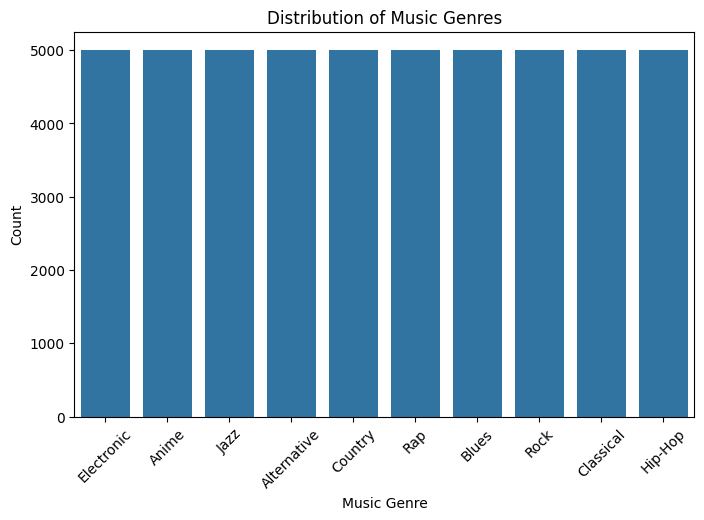

In [34]:
# Visualize the distribution of the target variable (music genre)
plt.figure(figsize=(8,5))
sns.countplot(x="music_genre", data=df)

plt.title("Distribution of Music Genres")
plt.xlabel("Music Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

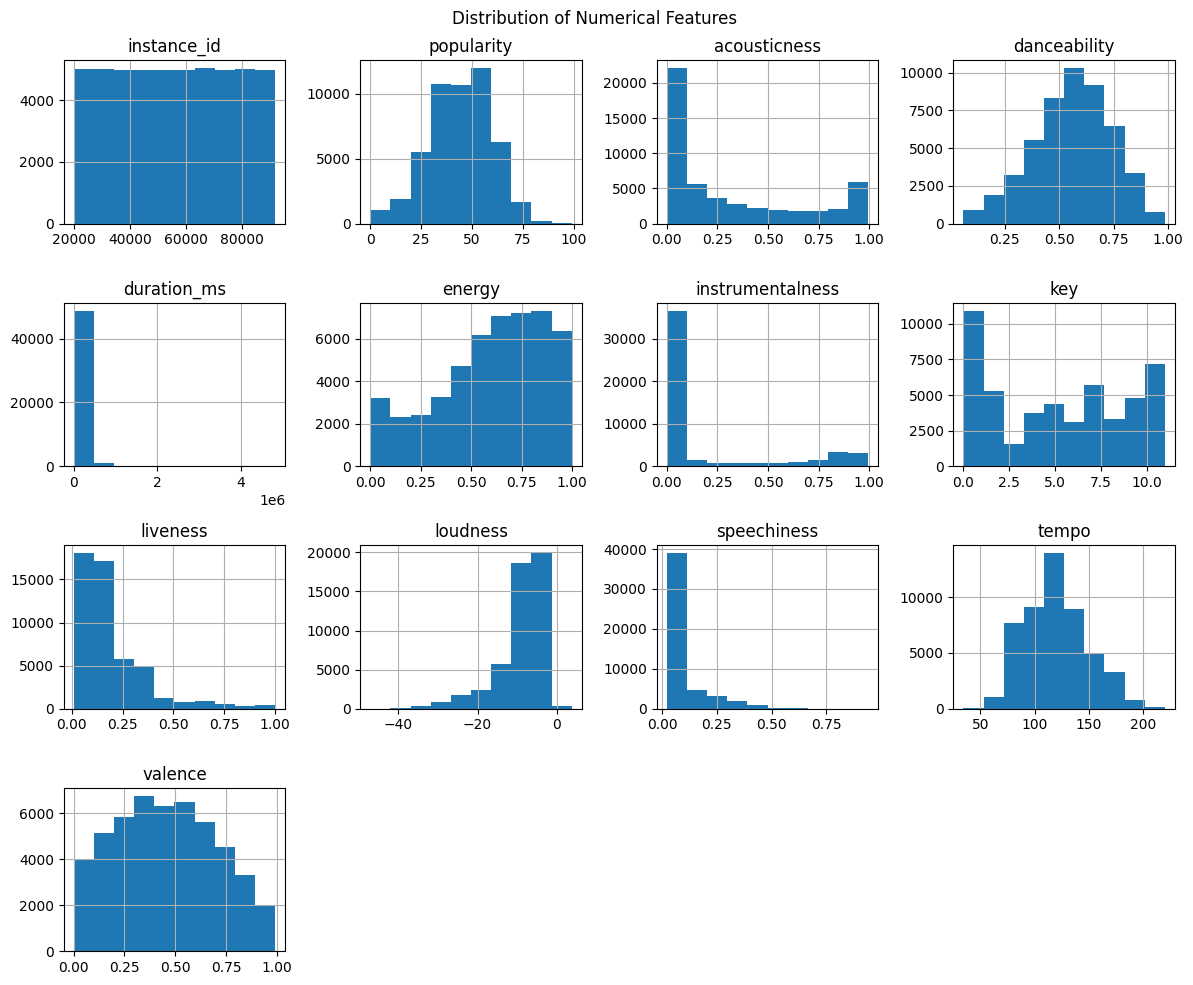

In [35]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Plot histograms for all numerical features
df[numeric_cols].hist(figsize=(12,10))

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

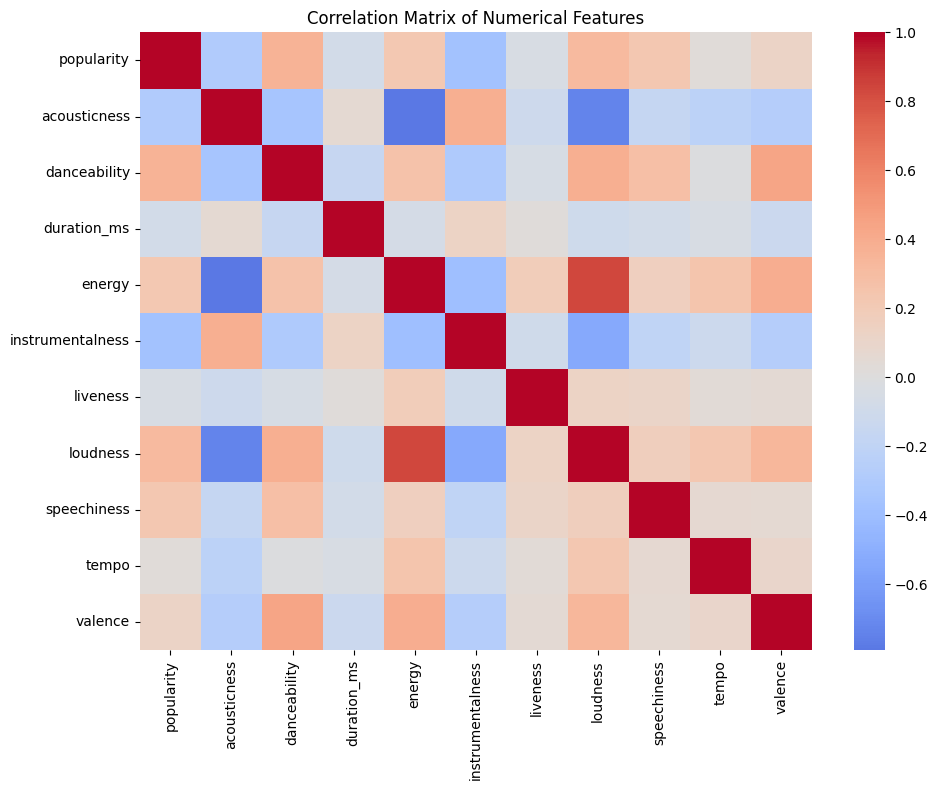

In [36]:
# Correlation analysis among numerical features

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Remove instance_id and key because it is only an identifier and not meaningful for correlation analysis
numeric_cols = [col for col in numeric_cols if col not in ["instance_id", "key"]]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [39]:
# Find highly correlated feature pairs

corr_pairs = corr.abs().unstack().sort_values(ascending=False)

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs < 1]

# Keep only one direction of each pair
corr_pairs = corr_pairs.drop_duplicates()

print("Top correlated feature pairs:")
print(corr_pairs.head(10))

Top correlated feature pairs:
energy            loudness            0.838399
acousticness      energy              0.791250
loudness          acousticness        0.730401
                  instrumentalness    0.529030
danceability      valence             0.434557
valence           energy              0.396317
danceability      loudness            0.390859
instrumentalness  energy              0.389730
acousticness      instrumentalness    0.387970
instrumentalness  popularity          0.364960
dtype: float64


/var/folders/30/p7qxyyh90n9d63j2qg87dh1r0000gn/T/ipykernel_54013/3842272204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="music_genre", y="energy", data=df, ax=axes[0,0], palette="Set2")
/var/folders/30/p7qxyyh90n9d63j2qg87dh1r0000gn/T/ipykernel_54013/3842272204.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="music_genre", y="danceability", data=df, ax=axes[0,1], palette="Set3")
/var/folders/30/p7qxyyh90n9d63j2qg87dh1r0000gn/T/ipykernel_54013/3842272204.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="music_genre", y="

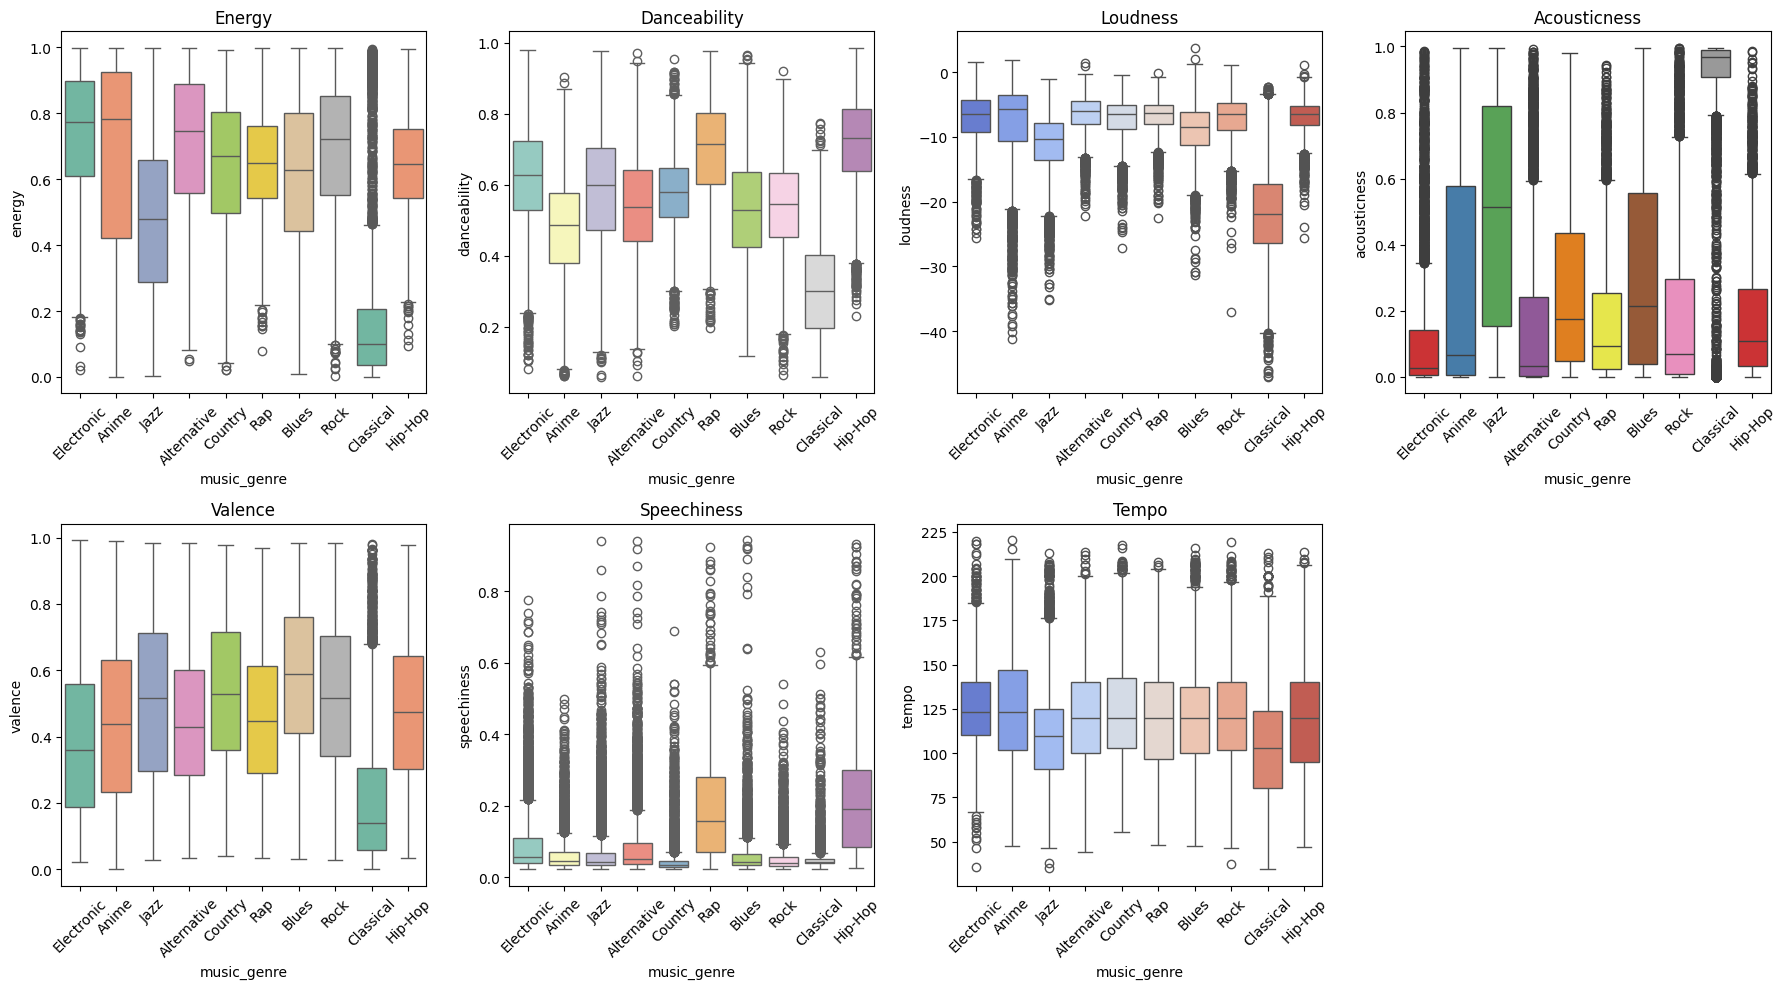

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(18,10))

# Row 1
sns.boxplot(x="music_genre", y="energy", data=df, ax=axes[0,0], palette="Set2")
axes[0,0].set_title("Energy")

sns.boxplot(x="music_genre", y="danceability", data=df, ax=axes[0,1], palette="Set3")
axes[0,1].set_title("Danceability")

sns.boxplot(x="music_genre", y="loudness", data=df, ax=axes[0,2], palette="coolwarm")
axes[0,2].set_title("Loudness")

sns.boxplot(x="music_genre", y="acousticness", data=df, ax=axes[0,3], palette="Set1")
axes[0,3].set_title("Acousticness")

# Row 2（可以再加几个）
sns.boxplot(x="music_genre", y="valence", data=df, ax=axes[1,0], palette="Set2")
axes[1,0].set_title("Valence")

sns.boxplot(x="music_genre", y="speechiness", data=df, ax=axes[1,1], palette="Set3")
axes[1,1].set_title("Speechiness")

sns.boxplot(x="music_genre", y="tempo", data=df, ax=axes[1,2], palette="coolwarm")
axes[1,2].set_title("Tempo")

fig.delaxes(axes[1,3])

# Rotate x labels
for row in axes:
    for ax in row:
        if ax:
            ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/var/folders/30/p7qxyyh90n9d63j2qg87dh1r0000gn/T/ipykernel_54013/1053266832.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="music_genre", y="energy", data=df, ax=axes[0], palette="Set2", showfliers=False)
/var/folders/30/p7qxyyh90n9d63j2qg87dh1r0000gn/T/ipykernel_54013/1053266832.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="music_genre", y="danceability", data=df, ax=axes[1], palette="Set3", showfliers=False)
/var/folders/30/p7qxyyh90n9d63j2qg87dh1r0000gn/T/ipykernel_54013/1053266832.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  s

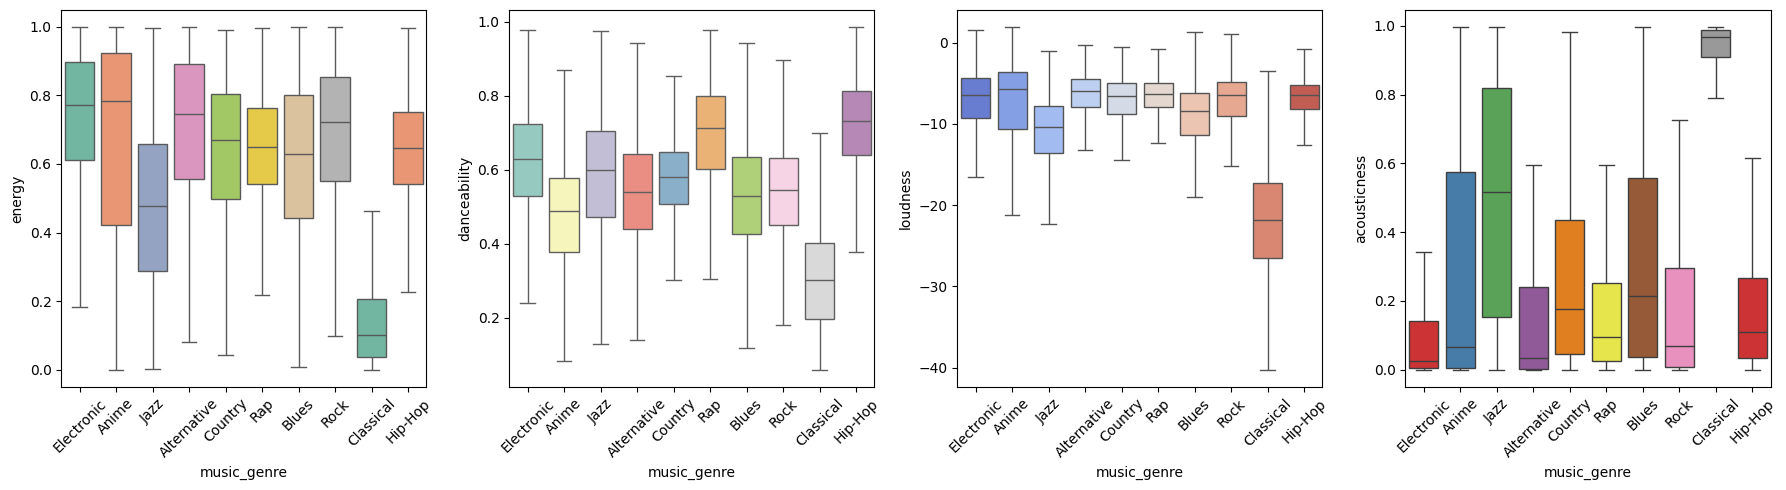

In [41]:
# No outliers
fig, axes = plt.subplots(1, 4, figsize=(18,5))

sns.boxplot(x="music_genre", y="energy", data=df, ax=axes[0], palette="Set2", showfliers=False)

sns.boxplot(x="music_genre", y="danceability", data=df, ax=axes[1], palette="Set3", showfliers=False)

sns.boxplot(x="music_genre", y="loudness", data=df, ax=axes[2], palette="coolwarm", showfliers=False)

sns.boxplot(x="music_genre", y="acousticness", data=df, ax=axes[3], palette="Set1", showfliers=False)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

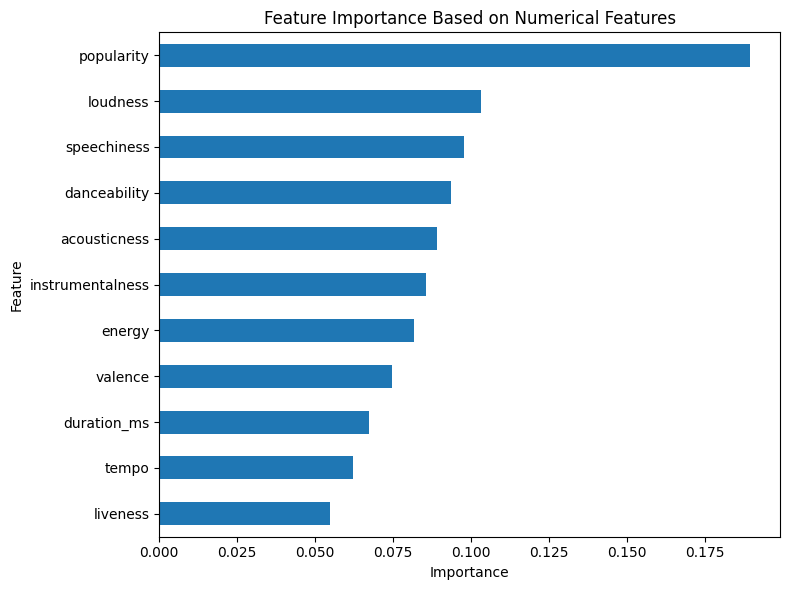

In [47]:
# Feature importance using only numerical features

# Select only numerical columns
X_num = df.select_dtypes(include=["int64", "float64"]).copy()

# Remove non-predictive identifier column if present
if "key" in X_num.columns:
    X_num = X_num.drop(columns=["key"])

# Remove non-predictive identifier column if present
if "instance_id" in X_num.columns:
    X_num = X_num.drop(columns=["instance_id"])

# Remove target if it was encoded as numeric by accident
if "music_genre" in X_num.columns:
    X_num = X_num.drop(columns=["music_genre"])

y = df["music_genre"]

# Fit Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_num, y)

# Store feature importance
importances = pd.Series(
    rf.feature_importances_,
    index=X_num.columns
).sort_values()

# Plot feature importance
plt.figure(figsize=(8,6))
importances.plot(kind="barh")

plt.title("Feature Importance Based on Numerical Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [48]:
# Analyze categorical variables (object-type columns)
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"{column}: {df[column].nunique()} unique labels")

artist_name: 6863 unique labels
track_name: 41699 unique labels
mode: 2 unique labels
obtained_date: 5 unique labels
music_genre: 10 unique labels


In [49]:
# Count number of unique artists and tracks
print("Number of unique artists:", df['artist_name'].nunique())
print("Number of unique tracks:", df['track_name'].nunique())

Number of unique artists: 6863
Number of unique tracks: 41699
